# Example-32: NUFFT applications

In [1]:
# In this example, similar to the previous one, NUFFT is used explicitly to bootstrap frequency
# Given a signal with noise, random samples (with repetition) are generated and NUFFT is performed in specified frequency interval
# This frequency interval can be identified from FFT, e.g. several bins around max bin frequency
# Also, NUFFTs from each sample are averaged to estimate the noise floor
# Additionally, frequency distribution is explored for a simple symplectic mapping for regular and chaotic initial conditions

In [2]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [3]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

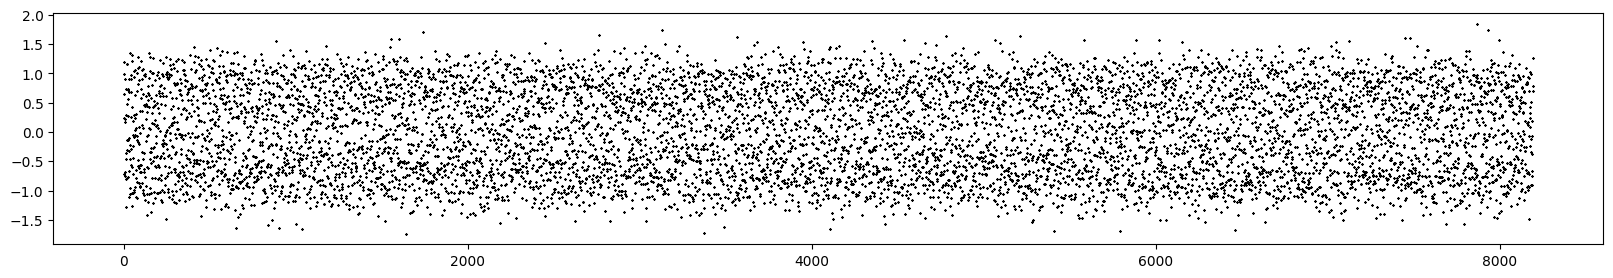

In [4]:
# Set parameters (1 signal with length 8192 and noise)

size, length = 1, 8192

# Set window

w = Window.from_cosine(length, order=1.0, dtype=dtype, device=device)

# Set TbT data (1 signals with two components and random noise)

t = torch.linspace(1.0, length, length , dtype=dtype, device=device)
s = torch.stack([i*torch.sin(2.0*numpy.pi*1*0.123456789*t) + 0.01*i*torch.sin(2.0*numpy.pi*2*0.123456789*t) for i in range(1, size + 1)])
s += 0.25*torch.randn(length, dtype=dtype, device=device)

# Convert to numpy and plot signal

s = (s.squeeze()).numpy()

plt.figure(figsize=(20, 3))
plt.scatter(t.cpu().numpy(), s, color='black', marker='x', s=1)
plt.show()

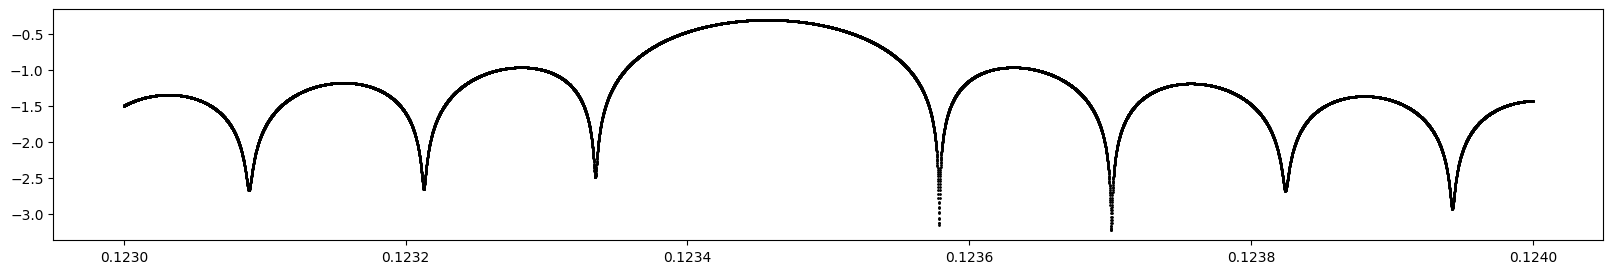

2.792032594706173e-07


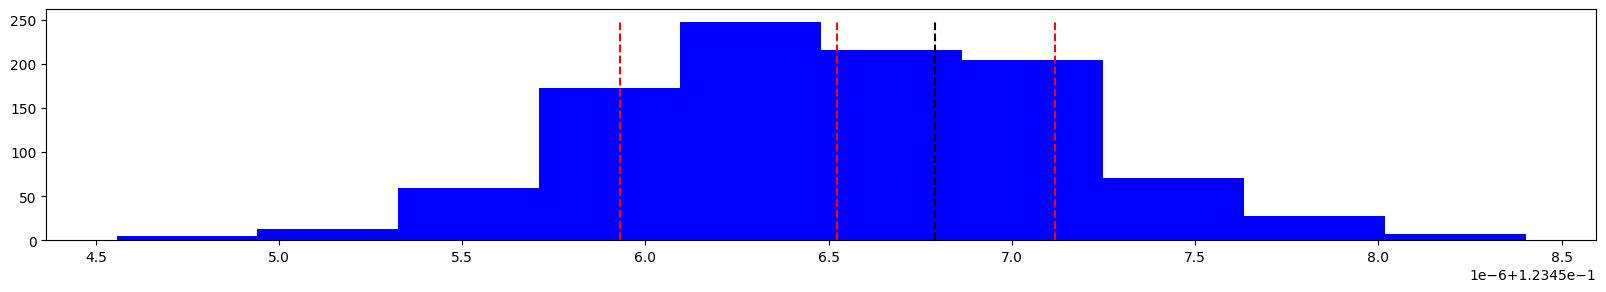

tensor(2.653741378450e-07, dtype=torch.float64)
tensor(5.940342032969e-07, dtype=torch.float64)


In [5]:
# Set initial frequency range
# Note, change range to zoom on the main maximum

f_min, f_max = 0.123, 0.124

# Generate (angular) frequencies
# Note, given a frequency range, resolution is defined by (f_max - f_min) over the number of frequency points

f = 2.0*numpy.pi*numpy.linspace(f_min, f_max, 2*len(t))

fft = nufft.nufft1d3(t, s, f)
plt.figure(figsize=(20, 3))
plt.scatter(f/(2.0*numpy.pi), numpy.log10(numpy.abs(fft)), color='black', s=1)
plt.show()

# Compute frequency from maximum
# Note, maximum can be fitted to obtain a potentialy more accurate result
# Frequency spread from full signal can be estimated from fit

print(abs(0.123456789 - f[numpy.argmax(numpy.abs(fft))]/(2.0*numpy.pi)))

# Perform bootstrap

# Set sample length and number of samples

limit = 8192
count = 1024

# Generate indices

index = torch.randint(limit, (count, limit), dtype=torch.int64, device=torch.device('cpu')).numpy()

# Compute frequencies for each sample

out = []
for i in index:
    out.append(f[numpy.argmax(numpy.abs(nufft.nufft1d3(t[i], s[i], f)))]/(2.0*numpy.pi))
out = torch.tensor(numpy.asarray(out), dtype=torch.float64)

# Plot frequency distribution
# Note, in this example frequency resolution is enough to see the effect of noise
# For small resolution the result will be 'quantized'
# Also the output can be cleaned from outliers

plt.figure(figsize=(20, 3))
plt.hist(out.cpu().numpy(), color='blue')
plt.vlines(0.123456789, 0, 250, linestyles='dashed', color='black')
plt.vlines([out.mean() - out.std(), out.mean(), out.mean() + out.std()], 0, 250, linestyles='dashed', color='red')
plt.show()

# Compute mean frequency and spread

print(abs(0.123456789 - out.mean()))
print(out.std())

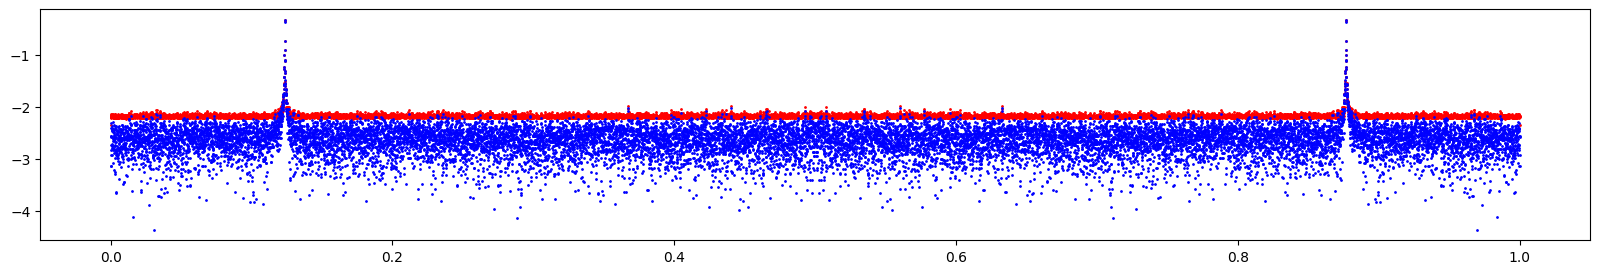

In [6]:
# Compute mean spectum

f_min, f_max = 0.0, 1.0
f = 2.0*numpy.pi*numpy.linspace(f_min, f_max, 2*len(t))

out = []
for i in index:
    out.append(numpy.log10(numpy.abs(nufft.nufft1d3(t[i], s[i], f))))
out = torch.tensor(numpy.asarray(out), dtype=torch.float64)

# Plot averaged spectrum vs full signal

plt.figure(figsize=(20, 3))
plt.scatter(f/(2.0*numpy.pi), out.T.mean(-1), color='red', s=1)
plt.scatter(f/(2.0*numpy.pi), numpy.log10(numpy.abs(nufft.nufft1d3(t, s, f))), color='blue', s=1)
plt.show()

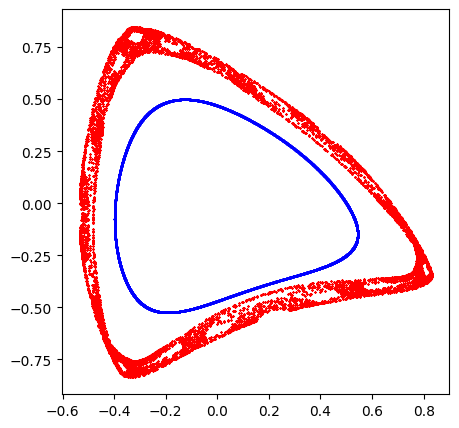

In [7]:
# Define nonlinear symplectic map

from math import pi

f1 = torch.tensor(2*pi*0.38, dtype=dtype, device=device)
f2 = torch.tensor(2*pi*0.41, dtype=dtype, device=device)

c1, s1 = f1.cos(), f1.sin()
c2, s2 = f2.cos(), f2.sin()

@torch.compile
def mapping(state):
    q1, p1, q2, p2 = state
    return torch.stack([c1*q1 + ((q1**2 - q2**2) + p1)*s1, c1*((q1**2 - q2**2) + p1) - q1*s1, c2*q2 + ((-2*q1*q2) + p2)*s2, c2*((-2*q1*q2) + p2) - q2*s2])

# Generate regular and chaotic orbits orbits

state = torch.tensor([0., 0., 0., 0.], dtype=dtype, device=device)
mapping(state)

regular = []
state = torch.tensor([0.50, 0., 0.01, 0.], dtype=dtype, device=device)
for _ in range(8192):
    state = mapping(state)
    regular.append(state)
regular = torch.stack(regular)

chaotic = []
state = torch.tensor([0.65, 0., 0.25, 0.], dtype=dtype, device=device)
for _ in range(8192):
    state = mapping(state)
    chaotic.append(state)
chaotic = torch.stack(chaotic)

q1, p1, q2, p2 = regular.T
Q1, P1, Q2, P2 = chaotic.T

# Plot otbits

plt.figure(figsize=(5, 5))
plt.scatter(q1.cpu().numpy(), p1.cpu().numpy(), marker='x', s=1, color='blue')
plt.scatter(Q1.cpu().numpy(), P1.cpu().numpy(), marker='x', s=1, color='red')
plt.show()

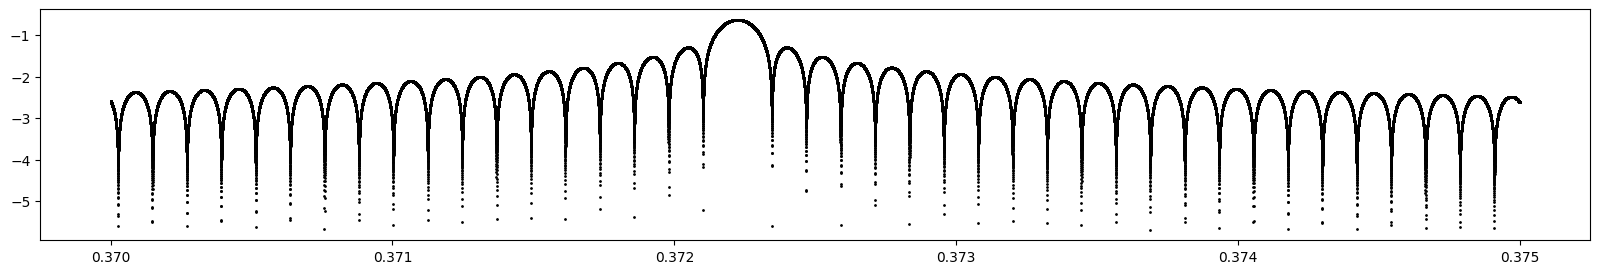

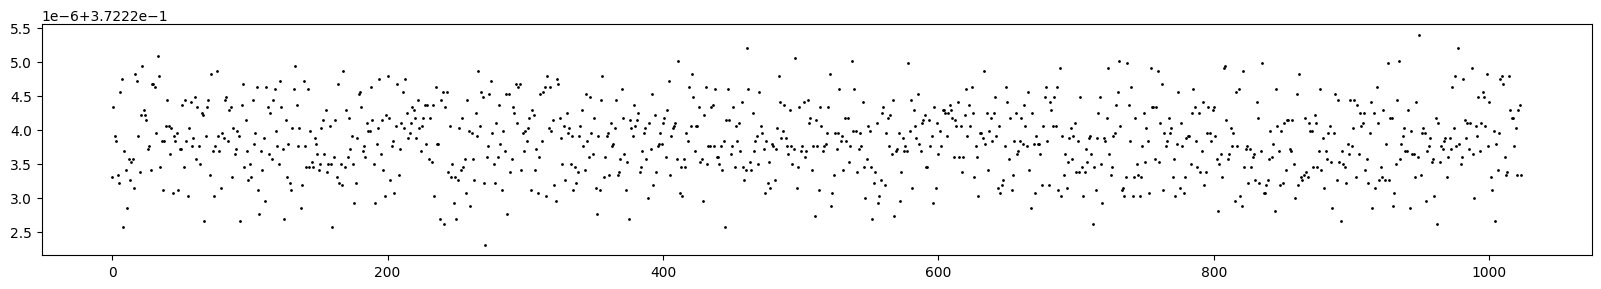

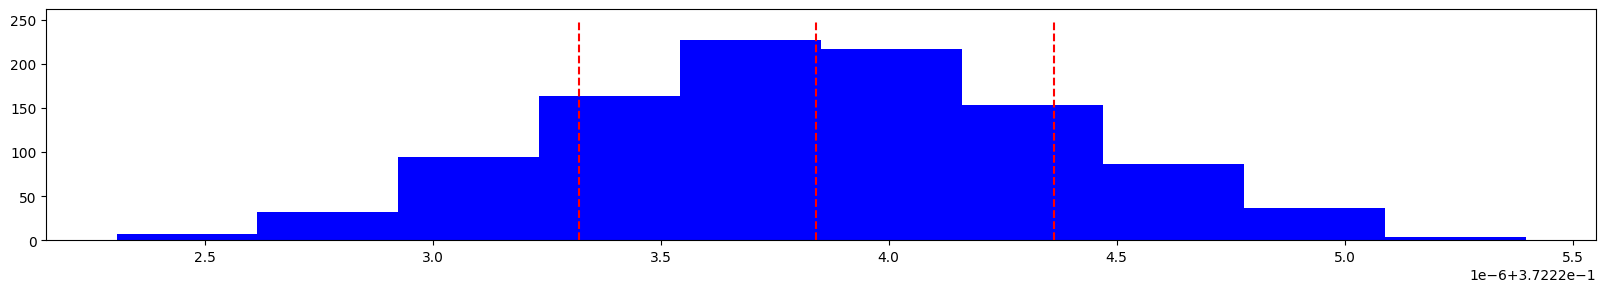

tensor(3.722238417880e-01, dtype=torch.float64)
tensor(5.203812691438e-07, dtype=torch.float64)


In [8]:
# Regular

l = len(q1)
t = torch.linspace(1.0, l, l , dtype=dtype, device=device)
f_min, f_max = 0.37, 0.375
f = 2.0*numpy.pi*numpy.linspace(f_min, f_max, 16*len(t))
s = q1.cpu().numpy()

fft = nufft.nufft1d3(t, s, f)

plt.figure(figsize=(20, 3))
plt.scatter(f/(2.0*numpy.pi), numpy.log10(numpy.abs(fft)), color='black', s=1)
plt.show()

limit = l
count = 1024
index = torch.randint(limit, (count, limit), dtype=torch.int64, device=torch.device('cpu')).numpy()
out = []
for i in index:
    out.append(f[numpy.argmax(numpy.abs(nufft.nufft1d3(t[i], s[i], f)))]/(2.0*numpy.pi))
out = torch.tensor(numpy.asarray(out), dtype=torch.float64)

plt.figure(figsize=(20, 3))
plt.scatter(range(len(out)), out.cpu().numpy(), color='black', s=1)
plt.show()

plt.figure(figsize=(20, 3))
plt.hist(out.cpu().numpy(), color='blue')
plt.vlines([out.mean() - out.std(), out.mean(), out.mean() + out.std()], 0, 250, linestyles='dashed', color='red')
plt.show()

print(out.mean())
print(out.std())

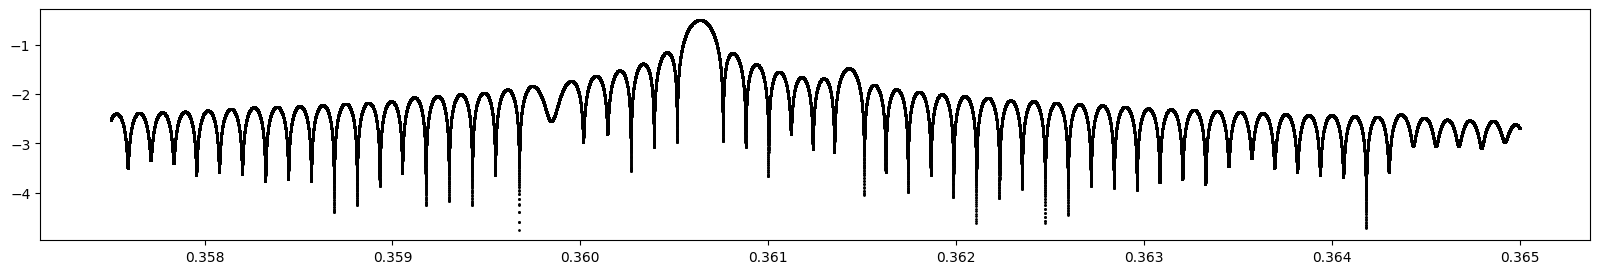

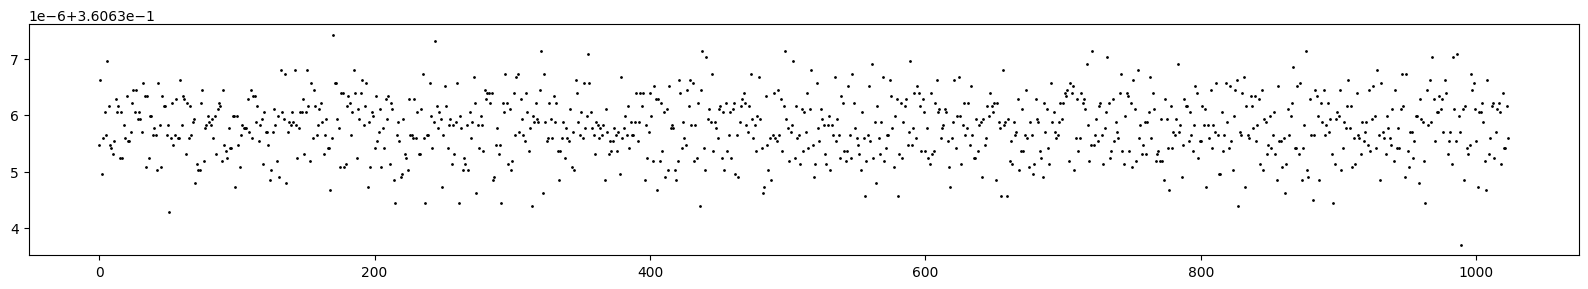

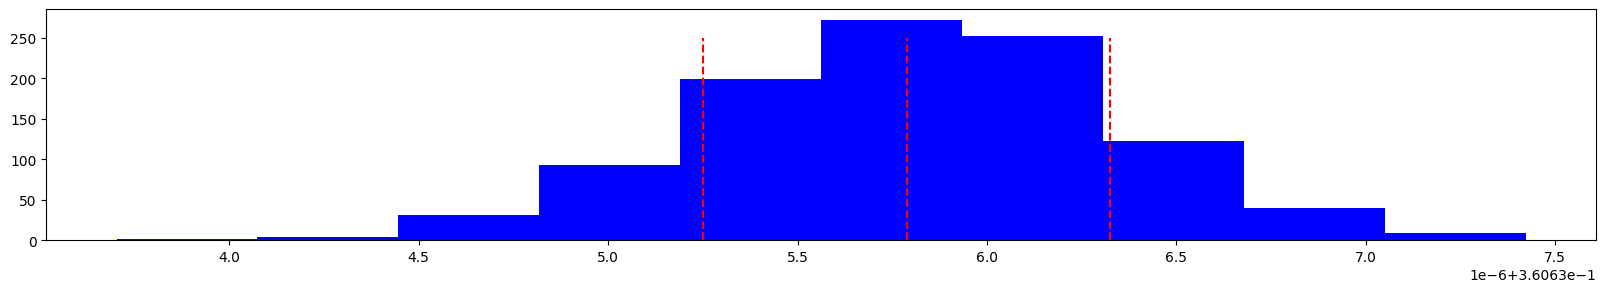

tensor(3.606357881132e-01, dtype=torch.float64)
tensor(5.377373930410e-07, dtype=torch.float64)


In [9]:
# Chaotic

l = len(Q1)
t = torch.linspace(1.0, l, l , dtype=dtype, device=device)
f_min, f_max = 0.3575, 0.3650
f = 2.0*numpy.pi*numpy.linspace(f_min, f_max, 16*len(t))
s = Q1.cpu().numpy()

fft = nufft.nufft1d3(t, s, f)

plt.figure(figsize=(20, 3))
plt.scatter(f/(2.0*numpy.pi), numpy.log10(numpy.abs(fft)), color='black', s=1)
plt.show()

limit = l
count = 1024
index = torch.randint(limit, (count, limit), dtype=torch.int64, device=torch.device('cpu')).numpy()
out = []
for i in index:
    out.append(f[numpy.argmax(numpy.abs(nufft.nufft1d3(t[i], s[i], f)))]/(2.0*numpy.pi))
out = torch.tensor(numpy.asarray(out), dtype=torch.float64)

plt.figure(figsize=(20, 3))
plt.scatter(range(len(out)), out.cpu().numpy(), color='black', s=1)
plt.show()

plt.figure(figsize=(20, 3))
plt.hist(out.cpu().numpy(), color='blue')
plt.vlines([out.mean() - out.std(), out.mean(), out.mean() + out.std()], 0, 250, linestyles='dashed', color='red')
plt.show()

print(out.mean())
print(out.std())